In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("outputs/tables", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)

In [2]:
df = pd.read_csv("GEFCom2014_prepared.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "hour"]).reset_index(drop=True)

df["hour"] = df["hour"].astype(int) - 1
df["day_of_week"] = df["day_of_week"].astype(int)
df["month"] = df["month"].astype(int) - 1
df["is_weekend"] = df["is_weekend"].astype(int)

In [3]:
load_features = ['load', 'lag_1', 'lag_24', 'load_roll_mean_24', 'load_roll_std_24']

temp_features = [
    'temp', 'temp_lag_1', 'temp_lag_24',
    'temp_roll_mean_24', 'temp_roll_std_24',
    'CDD', 'HDD'
]

calendar_features = ['hour', 'day_of_week', 'month', 'is_weekend']
target_col = "load"

In [4]:
SEQ_LEN = 24

class DatasetRQ7(Dataset):
    def __init__(self, df):
        self.Xl = df[load_features].values.astype(np.float32)
        self.Xt = df[temp_features].values.astype(np.float32)
        self.Xc = df[calendar_features].values.astype(np.int64)
        self.y = df[target_col].values.astype(np.float32)

    def __len__(self):
        return len(self.Xl) - SEQ_LEN

    def __getitem__(self, idx):
        return (
            torch.tensor(self.Xl[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xt[idx:idx+SEQ_LEN]),
            torch.tensor(self.Xc[idx:idx+SEQ_LEN]),
            torch.tensor(self.y[idx+SEQ_LEN])
        )

dataset = DatasetRQ7(df)

train_size = int(0.8 * len(dataset))
train_ds, test_ds = torch.utils.data.random_split(
    dataset, [train_size, len(dataset) - train_size]
)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=64)

In [5]:
class AdaptiveFusionModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.attention = nn.Sequential(
            nn.Linear(64 + 32 + 18, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Sigmoid()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal = torch.cat([
            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])
        ], dim=1)

        combined = torch.cat([load_out, temp_out, cal], dim=1)
        weights = self.attention(combined)

        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal = weights[:, 2].unsqueeze(1)

        fused = torch.cat([
            load_out * (1 + w_load),
            temp_out * (1 + w_temp),
            cal * (1 + w_cal)
        ], dim=1)

        return self.fc(fused)

In [6]:
class AdaptiveQuantileModel(nn.Module):
    def __init__(self, quantiles):
        super().__init__()
        self.quantiles = quantiles

        self.lstm = nn.LSTM(len(load_features), 64, batch_first=True)

        self.temp_mlp = nn.Sequential(
            nn.Linear(len(temp_features), 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.hour_emb = nn.Embedding(24, 8)
        self.day_emb = nn.Embedding(7, 4)
        self.month_emb = nn.Embedding(12, 4)
        self.weekend_emb = nn.Embedding(2, 2)

        self.attention = nn.Sequential(
            nn.Linear(64 + 32 + 18, 32),
            nn.ReLU(),
            nn.Linear(32, 3),
            nn.Sigmoid()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 + 32 + 18, 64),
            nn.ReLU(),
            nn.Linear(64, len(quantiles))
        )

    def forward(self, Xl, Xt, Xc):
        _, (h, _) = self.lstm(Xl)
        load_out = h[-1]

        temp_out = self.temp_mlp(Xt[:, -1, :])

        cal = torch.cat([
            self.hour_emb(Xc[:, -1, 0]),
            self.day_emb(Xc[:, -1, 1]),
            self.month_emb(Xc[:, -1, 2]),
            self.weekend_emb(Xc[:, -1, 3])
        ], dim=1)

        combined = torch.cat([load_out, temp_out, cal], dim=1)
        weights = self.attention(combined)

        w_load = weights[:, 0].unsqueeze(1)
        w_temp = weights[:, 1].unsqueeze(1)
        w_cal = weights[:, 2].unsqueeze(1)

        fused = torch.cat([
            load_out * (1 + w_load),
            temp_out * (1 + w_temp),
            cal * (1 + w_cal)
        ], dim=1)

        return self.fc(fused)

In [7]:
def quantile_loss(preds, target, quantiles):
    loss = 0
    for i, q in enumerate(quantiles):
        errors = target - preds[:, i]
        loss += torch.mean(torch.max((q - 1) * errors, q * errors))
    return loss

In [8]:
def train_baseline(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    for epoch in range(10):
        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(Xl, Xt, Xc).squeeze()

            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

In [9]:
def train_quantile(model, quantiles):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(10):
        for Xl, Xt, Xc, y in train_loader:
            Xl, Xt, Xc, y = Xl.to(device), Xt.to(device), Xc.to(device), y.to(device)

            optimizer.zero_grad()
            preds = model(Xl, Xt, Xc)

            loss = quantile_loss(preds, y, quantiles)
            loss.backward()
            optimizer.step()

In [10]:
quantiles = [0.1, 0.5, 0.9]

baseline_model = AdaptiveFusionModel().to(device)
quantile_model = AdaptiveQuantileModel(quantiles).to(device)

train_baseline(baseline_model)
train_quantile(quantile_model, quantiles)

In [11]:
def evaluate_models():
    baseline_preds, p50, p90, actual = [], [], [], []

    with torch.no_grad():
        for Xl, Xt, Xc, y in test_loader:
            Xl, Xt, Xc = Xl.to(device), Xt.to(device), Xc.to(device)

            b = baseline_model(Xl, Xt, Xc).cpu().numpy().flatten()
            q = quantile_model(Xl, Xt, Xc).cpu().numpy()

            baseline_preds.extend(b)
            p50.extend(q[:,1])
            p90.extend(q[:,2])
            actual.extend(y.numpy())

    return np.array(baseline_preds), np.array(p50), np.array(p90), np.array(actual)

baseline_preds, p50, p90, actual = evaluate_models()

In [12]:
threshold = np.percentile(actual, 95)

actual_peaks = actual > threshold
alerts_quantile = p90 > threshold
alerts_baseline = baseline_preds > threshold

In [13]:
alert_results = pd.DataFrame({
    "Model": ["Baseline", "Adaptive + Quantile"],
    "Precision": [
        precision_score(actual_peaks, alerts_baseline),
        precision_score(actual_peaks, alerts_quantile)
    ],
    "Recall": [
        recall_score(actual_peaks, alerts_baseline),
        recall_score(actual_peaks, alerts_quantile)
    ]
})

alert_results

,Model,Precision,Recall
0,Baseline,0.805970,0.618321
1,Adaptive + Quantile,0.467135,0.931298


In [14]:
planning_results = pd.DataFrame({
    "Strategy": ["Baseline", "Uncertainty-aware (P90)"],
    "Underestimation": [
        np.mean(baseline_preds < actual),
        np.mean(p90 < actual)
    ],
    "Overestimation": [
        np.mean(baseline_preds > actual),
        np.mean(p90 > actual)
    ]
})

planning_results

,Strategy,Underestimation,Overestimation
0,Baseline,0.496282,0.503718
1,Uncertainty-aware (P90),0.082491,0.917509


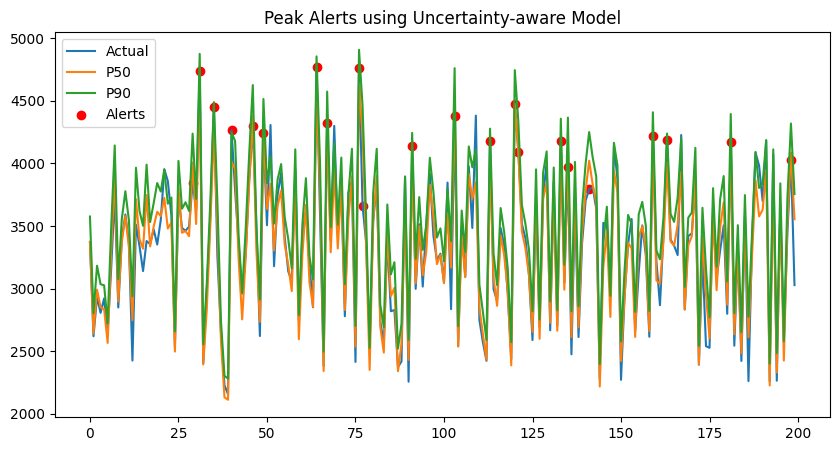

In [16]:
plt.figure(figsize=(10,5))

plt.plot(actual[:200], label="Actual")
plt.plot(p50[:200], label="P50")
plt.plot(p90[:200], label="P90")

alerts_idx = np.where(alerts_quantile[:200])[0]
plt.scatter(alerts_idx, actual[:200][alerts_idx], color='red', label="Alerts")

plt.legend()
plt.title("Peak Alerts using Uncertainty-aware Model")

plt.savefig("outputs/figures/rq7_peak_alerts.pdf")

plt.show()